# Duma hse nlp project. RNN and generate text.

In [ ]:
!mkdir /content/dumas_books

mkdir: cannot create directory ‘/content/dumas_books’: File exists


In [ ]:
!unrar x /content/Alexandre_Dumas.rar /content/dumas_books/


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal

Unexpected end of archive

Extracting from /content/Alexandre_Dumas.rar


Would you like to replace the existing file /content/dumas_books/Alexandre_Dumas-Marquise_De_Ganges.txt
125545 bytes, modified on 2025-04-11 18:38
with a new one
125545 bytes, modified on 2025-04-11 18:38

[Y]es, [N]o, [A]ll, n[E]ver, [R]ename, [Q]uit A

Extracting  /content/dumas_books/Alexandre_Dumas-Marquise_De_Ganges.txt       0%  OK 
Extracting  /content/dumas_books/Alexandre_Dumas-Marquise_Brinvillier.txt       1%  OK 
Extracting  /content/dumas_books/Alexandre_Dumas-Marguerite_De_Valois.txt       6%  OK 
Extracting  /content/dumas_books/Alexandre_Dumas-Derues.txt                8%  OK 
Extracting  /content/dumas_books/Alexandre_Dumas-Louise_De_La_Valliere.txt      12%  OK 
Extracting  /content/dumas_books/Alexandre_Dumas-Cenci.txt                13%  OK 
Extracting  /content/duma

Let's begin with importing dependencies

In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.model_selection import train_test_split
from collections import Counter
from typing import List

## Choosing a literature and creating the vocabulary

In [ ]:
import os
from nltk.tokenize import sent_tokenize

dumas_folder = '/content/dumas_books/'
dumas_file_paths = [os.path.join(dumas_folder, f) for f in os.listdir(dumas_folder) if f.endswith('.txt')]

In [ ]:
dumas_file_paths

['/content/dumas_books/Alexandre_Dumas-The_Man_In_The_Iron_Mask.txt',
 '/content/dumas_books/Alexandre_Dumas-The_Companions_Of_Jehu.txt',
 '/content/dumas_books/Alexandre_Dumas-The_Vicomte_De_Bragelonne.txt',
 '/content/dumas_books/Alexandre_Dumas-Murat.txt',
 '/content/dumas_books/Alexandre_Dumas-The_Black_Tulip.txt',
 '/content/dumas_books/Alexandre_Dumas-Marquise_Brinvillier.txt',
 '/content/dumas_books/Alexandre_Dumas-Vicomte_De_Bragelonne.txt',
 '/content/dumas_books/Alexandre_Dumas-Ten_Years_Later.txt',
 '/content/dumas_books/Alexandre_Dumas-Louise_De_La_Valliere.txt',
 '/content/dumas_books/Alexandre_Dumas-Marquise_De_Ganges.txt',
 '/content/dumas_books/Alexandre_Dumas-Vaninka.txt',
 '/content/dumas_books/Alexandre_Dumas-Cenci.txt',
 '/content/dumas_books/Alexandre_Dumas-The_Three_Musketeers.txt',
 '/content/dumas_books/Alexandre_Dumas-The_Count_Of_Monte_Cristo.txt',
 '/content/dumas_books/Alexandre_Dumas-Massacres_Of_The_South_(1551_1815).txt',
 '/content/dumas_books/Alexandre_

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Ok. Now we tokenize each book on sentences and put it in a dictionary

In [ ]:
sentences_dumas = {}

for i, file_path in enumerate(dumas_file_paths, 1):
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as file:
        text = file.read()
        sentences = sent_tokenize(text)
        variable_name = f'sentences_dumas_{i}'
        sentences_dumas[variable_name] = sentences

len(sentences_dumas)

25

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Now we want to do a single list with all 25 books sentences

In [ ]:
sentences_lists = sentences_dumas.values()
all_sentences_duma = [sentence for sentences_list in sentences_lists for sentence in sentences_list]

In [ ]:
len(all_sentences_duma)

198249

Wow! We have 198249 sentences! Duma has done an enormous amount of work!

In [ ]:
for sentence in all_sentences_duma[100:105]:
    print(sentence)

Even worse, Fouquet,
desperate for money, is forced to sell the parliamentary position that
renders him untouchable by any court proceedings.
As part of her deal
with Colbert, though, Chevreuse also obtains a secret audience with the
queen-mother, where the two discuss a shocking secret--Louis XIV has a
twin brother, long believed, however, to be dead.
Meanwhile, in other quarters, De Wardes, Raoul's inveterate enemy, has
returned from Calais, barely recovered from his wounds, and no sooner
does he return than he begins again to insult people, particularly La
Valliere, and this time the comte de Guiche is the one to challenge him.
The duel leaves De Guiche horribly wounded, but enables Madame to use
her influence to destroy De Wardes's standing at court.
The _fetes_,
however, come to an end, and the court returns to Paris.


In [ ]:
sentences_duma_data = pd.DataFrame(all_sentences_duma)

In [ ]:
random_rows = sentences_duma_data.sample(n=20)
print(random_rows)

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                0
131373                                                                

Now we choose sentences <= 32 words

In [ ]:
all_sentences_duma_new = []
word_threshold = 32

for text in tqdm(all_sentences_duma):
    cleaned_text = text.replace('\\', '')
    all_sentences_duma_new.extend(
        [x.lower() for x in sent_tokenize(text.replace('\n', ''),\
                                          language='english') if len(word_tokenize(x)) < word_threshold])

  0%|          | 0/198249 [00:00<?, ?it/s]

In [ ]:
all_sentences_duma_new[:5]

["the man in the iron mask we'refamiliar with today is the last volume of the four-volume edition.",
 "[not all the editions split them in the same manner, hence some of theconfusion...but wait...there's yet more reason for confusion.]",
 "one thing that may be causing confusion is that the etext we have now,entitled ten years later, says it's the sequel to the three musketeers.",
 "while this is technically true, there's another book, twenty yearsafter, that comes between.",
 "also, the third book of thed'artagnan romances, while entitled the vicomte de bragelonne, has thesubtitle ten years later."]

In [ ]:
print("Number of all sentences:", len(all_sentences_duma_new))

Number of all sentences: 154220


Now we will calculate the frequency of words in all the Duma books

In [ ]:
words = Counter()
for sentence in tqdm(all_sentences_duma_new):
    for word in word_tokenize(sentence):
        words[word] += 1

  0%|          | 0/154220 [00:00<?, ?it/s]

In [ ]:
len(words)

72069

Wow! 72,000 words. What an impressive vocabulary!

In [ ]:
first_30 = words.most_common(30)
# Print the first 30 key-value pairs
for word, count in first_30:
    print(word, count)

, 151258
. 110932
the 89129
'' 84544
`` 72010
to 42546
of 37570
and 36577
you 30969
i 29932
a 29239
? 24200
he 22306
! 20925
in 20733
that 20005
his 18018
it 17587
is 17186
was 16811
; 16138
said 14934
not 14193
with 11885
at 11123
my 10901
have 10876
but 10555
me 10494
for 10314


Interesting. We see many prepositions, articles, pronouns, and conjunctions, and no names...

Now we take 30k words (its enough!) of 72k words to exclude rare words from our vocabulary for training language models. And for faster training ofc!

In [ ]:
vocab = set()
vocab_size = 30000
vocab = set(['<unk>', '<bos>', '<eos>', '<pad>'])
for word, cnt in words.most_common()[:vocab_size]:
  vocab.add(word)

In [ ]:
assert '<unk>' in vocab
assert '<bos>' in vocab
assert '<eos>' in vocab
assert '<pad>' in vocab
assert len(vocab) == vocab_size + 4

In [ ]:
print("All words in vocabulary:", len(vocab))

All words in vocabulary: 30004


In [ ]:
word2ind = {char: i for i, char in enumerate(vocab)}
ind2word = {i: char for char, i in word2ind.items()}

## Doing some preparations for models training

After that we code class WordDataset, add some padding to batch etc.

In [ ]:
class WordDataset:
    def __init__(self, sentences):
        self.data = sentences
        self.unk_id = word2ind['<unk>']
        self.bos_id = word2ind['<bos>']
        self.eos_id = word2ind['<eos>']
        self.pad_id = word2ind['<pad>']

    def __getitem__(self, idx: int) -> List[int]:
        tokenized_sentence = [self.bos_id]
        tokenized_sentence += [word2ind.get(word, self.unk_id) for word in word_tokenize(self.data[idx])]
        tokenized_sentence += [self.eos_id]

        return tokenized_sentence

    def __len__(self) -> int:
        return len(self.data)

In [ ]:
def collate_fn_with_padding(
    input_batch: List[List[int]], pad_id=word2ind['<pad>']) -> torch.Tensor:
    seq_lens = [len(x) for x in input_batch]
    max_seq_len = max(seq_lens)

    new_batch = []
    for sequence in input_batch:
        for _ in range(max_seq_len - len(sequence)):
            sequence.append(pad_id)
        new_batch.append(sequence)

    sequences = torch.LongTensor(new_batch).to(device)

    new_batch = {
        'input_ids': sequences[:,:-1],
        'target_ids': sequences[:,1:]
    }

    return new_batch

Now lets split out sentences to train, eval and test sentences. We will use test sentences to measure perplexity

In [ ]:
train_sentences, eval_sentences = train_test_split(all_sentences_duma_new, test_size=0.2)
eval_sentences, test_sentences = train_test_split(eval_sentences, test_size=0.5)

train_dataset = WordDataset(train_sentences)
eval_dataset = WordDataset(eval_sentences)
test_dataset = WordDataset(test_sentences)

batch_size = 128

train_dataloader = DataLoader(
    train_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

eval_dataloader = DataLoader(
    eval_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

test_dataloader = DataLoader(
    test_dataset, collate_fn=collate_fn_with_padding, batch_size=batch_size)

In [ ]:
def evaluate(model, criterion, dataloader) -> float:
    model.eval()
    perplexity = []
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            perplexity.append(torch.exp(loss).item())

    perplexity = sum(perplexity) / len(perplexity)

    return perplexity

Train cycle

In [ ]:
def train_model(net, hidden_dim, vocab_size, epochs, train_dataloader,\
                eval_dataloader, lr=0.001, rnn=nn.RNN, num_layers=1):

    model = net(hidden_dim=hidden_dim, vocab_size=vocab_size, layer=rnn,\
                num_layers=num_layers).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses_train = []
    perplexities_train = []
    losses_val = []
    perplexities_val = []

    for epoch in range(epochs):
        epoch_losses = []
        avg_loss_val = []
        perplexity = []
        perplexity_v = []
        model.train()
        for batch in tqdm(train_dataloader, desc=f'Training epoch {epoch}:'):
            optimizer.zero_grad()
            logits = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
            loss = criterion(logits, batch['target_ids'].flatten())
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())
            perplexity.append(torch.exp(loss).item())

        losses_train.append(sum(epoch_losses) / len(epoch_losses))
        perplexities_train.append(sum(perplexity) / len(perplexity))

        model.eval()
        with torch.no_grad():
            for batch in eval_dataloader:
                logits_val = model(batch['input_ids']).flatten(start_dim=0, end_dim=1)
                loss_val = criterion(logits_val, batch['target_ids'].flatten())
                avg_loss_val.append(loss_val.item())
                perplexity_v.append(torch.exp(loss_val).item())

        losses_val.append(sum(avg_loss_val) / len(avg_loss_val))
        perplexities_val.append(sum(perplexity_v) / len(perplexity_v))

    return (losses_train, losses_val, perplexities_train, perplexities_val, model)

Lets code LanguageModel class. We will use simple models.

In [ ]:
class LanguageModel(nn.Module):
    def __init__(self, hidden_dim: int, vocab_size: int, layer=nn.RNN, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, hidden_dim)
        self.rnn = layer(hidden_dim, hidden_dim, batch_first=True, num_layers=num_layers)
        self.linear = nn.Linear(hidden_dim, hidden_dim)
        self.projection = nn.Linear(hidden_dim, vocab_size)
        self.non_lin = nn.Tanh()
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, input_batch: torch.Tensor) -> torch.Tensor:
        embeddings = self.embedding(input_batch)  # [batch_size, seq_len, hidden_dim]
        output, _ = self.rnn(embeddings)  # [batch_size, seq_len, hidden_dim]
        output = self.dropout(self.linear(self.non_lin(output)))  # [batch_size, seq_len, hidden_dim]
        projection = self.projection(self.non_lin(output))  # [batch_size, seq_len, vocab_size]

        return projection

In [ ]:
def plot_all(losses_tr, losses_val, perplexities_tr, perplexities_val):
  fig, axes = plt.subplots(2, 2, figsize=(8, 8))

  # Losses
  axes[0, 0].plot(np.arange(len(losses_tr)), losses_tr)
  axes[0, 0].set_title('Train Losses')
  axes[0, 0].set_xlabel('Epoch')

  axes[0, 1].plot(np.arange(len(losses_val)), losses_val)
  axes[0, 1].set_title('Validation Losses')
  axes[0, 1].set_xlabel('Epoch')

  # Perplexity
  axes[1, 0].plot(np.arange(len(perplexities_tr)), perplexities_tr)
  axes[1, 0].set_title('Train Perplexity')
  axes[1, 0].set_xlabel('Epoch')

  axes[1, 1].plot(np.arange(len(perplexities_val)), perplexities_val)
  axes[1, 1].set_title('Validation Perplexity')
  axes[1, 1].set_xlabel('Epoch')

  plt.tight_layout()
  plt.show()

And in the end lets code function for sentence generating

In [ ]:
def generate_sequence(model, starting_seq: str, max_seq_len: int = 256) -> str:
  device = 'cpu'
  model = model.to(device)
  input_ids = [word2ind['<bos>']] + [
    word2ind.get(char, word2ind['<unk>']) for char in word_tokenize(starting_seq)]
  input_ids = torch.LongTensor(input_ids).to(device)
  model.eval()
  with torch.no_grad():
    for i in range(max_seq_len):
      next_char_distribution = model(input_ids)[-1]
      next_char = next_char_distribution.squeeze().argmax()
      input_ids = torch.cat([input_ids, next_char.unsqueeze(0)])
      if next_char.item() == word2ind['<eos>']:
        break
  words = ' '.join([ind2word.get(idx.item(), '<unk>') for idx in input_ids])
  return words

## Experiment 1. We use simple 1-layer RNN here

In [ ]:
%%time

losses_tr_1, losses_val_1, perplexities_tr_1, perplexities_val_1, model_1 =\
train_model(LanguageModel, hidden_dim=256, vocab_size=len(vocab), epochs=7,\
             train_dataloader=train_dataloader, eval_dataloader=eval_dataloader, lr=0.001, num_layers=1)

Training epoch 0::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/964 [00:00<?, ?it/s]

CPU times: user 9min 32s, sys: 2.29 s, total: 9min 34s
Wall time: 9min 45s


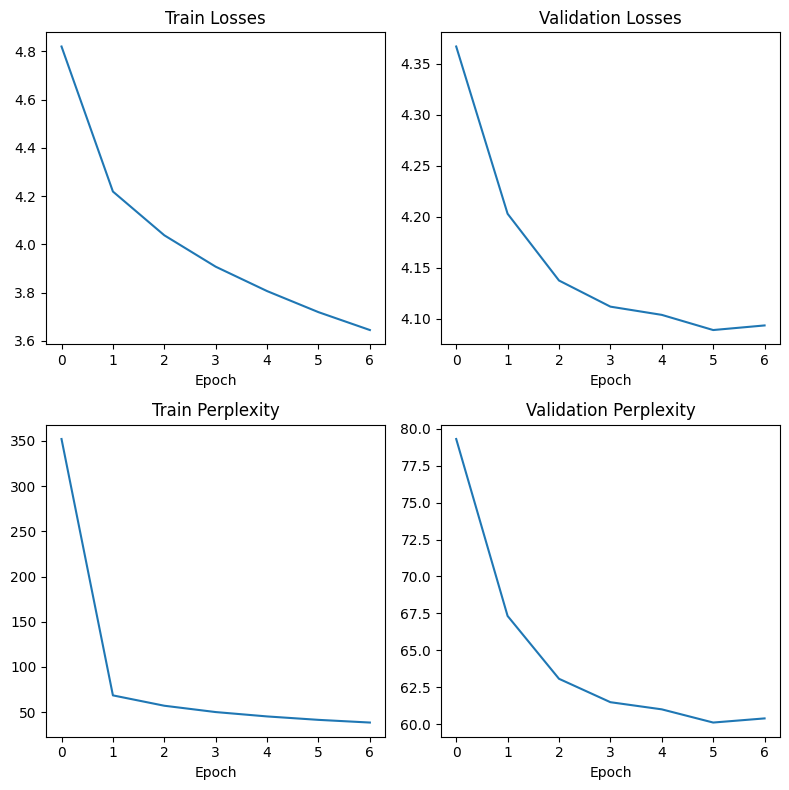

Perplexity on test:  60


In [ ]:
plot_all(losses_tr_1, losses_val_1, perplexities_tr_1, perplexities_val_1)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
print('Perplexity on test: ', round(evaluate(model_1, criterion, test_dataloader)))

60 perplexity, not bad. Then i use this model with 'imdb dataset', the perplexity was around 100.

Lets save this model:

In [ ]:
import joblib
from google.colab import files

class ModelWrapper:
    def __init__(self, model):
        self.model = model
        self.model.eval()

wrapper = ModelWrapper(model_1)

joblib_path = '/content/model_1_wrapper.joblib'
joblib.dump(wrapper, joblib_path)

files.download(joblib_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
(
generate_sequence(model_1, starting_seq='young d’artagnan arrived in paris with nothing but a sword and a dream to '),
generate_sequence(model_1, starting_seq='athos is a man who '),
generate_sequence(model_1, starting_seq='aramis believed that '),
generate_sequence(model_1, starting_seq='milady de winter, with a faint smile on her lips and a dagger in her sleeve, was ready to '),
generate_sequence(model_1, starting_seq='monte cristo knew that ')
)

('<bos> young d ’ artagnan arrived in paris with nothing but a sword and a dream to the king . <eos>',
 "<bos> athos is a man who has been stolen from the king . '' <eos>",
 '<bos> aramis believed that he was not mistaken . <eos>',
 '<bos> milady de winter , with a faint smile on her lips and a dagger in her sleeve , was ready to be <unk> . <eos>',
 '<bos> monte cristo knew that he was not mistaken . <eos>')

Now lets generate questions

In [ ]:
(
generate_sequence(model_1, starting_seq='is d’artagnan going to challenge him to a duel, or '),
generate_sequence(model_1, starting_seq='was athos ever able to forget milady, or '),
generate_sequence(model_1, starting_seq='does the count of monte cristo truly believe in justice, or '),
generate_sequence(model_1, starting_seq='who poisoned the wine at the cardinal’s banquet, and '),
generate_sequence(model_1, starting_seq='should edmond dantès reveal his true identity now, or ')
)

('<bos> is d ’ artagnan going to challenge him to a duel , or rather , and i will not be able to do . <eos>',
 '<bos> was athos ever able to forget milady , or rather the <unk> . <eos>',
 "<bos> does the count of monte cristo truly believe in justice , or rather ? '' <eos>",
 "<bos> who poisoned the wine at the cardinal ’ s banquet , and i will not ? '' <eos>",
 '<bos> should edmond <unk> reveal his true identity now , or rather the <unk> . <eos>')

We can see a little problem with "unks".

### Experiment 2. Lets take LSTM layer

In [ ]:
%%time

losses_tr_exp_2, losses_val_exp_2, perplexities_tr_exp_2, perplexities_val_exp_2, model_2 =\
train_model(LanguageModel, hidden_dim=256, vocab_size=len(vocab), epochs=7,\
            train_dataloader=train_dataloader, eval_dataloader=eval_dataloader,\
            lr=0.001, rnn=nn.LSTM, num_layers=1)

Training epoch 0::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 1::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 2::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 3::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 4::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 5::   0%|          | 0/964 [00:00<?, ?it/s]

Training epoch 6::   0%|          | 0/964 [00:00<?, ?it/s]

CPU times: user 9min 49s, sys: 2.13 s, total: 9min 51s
Wall time: 9min 57s


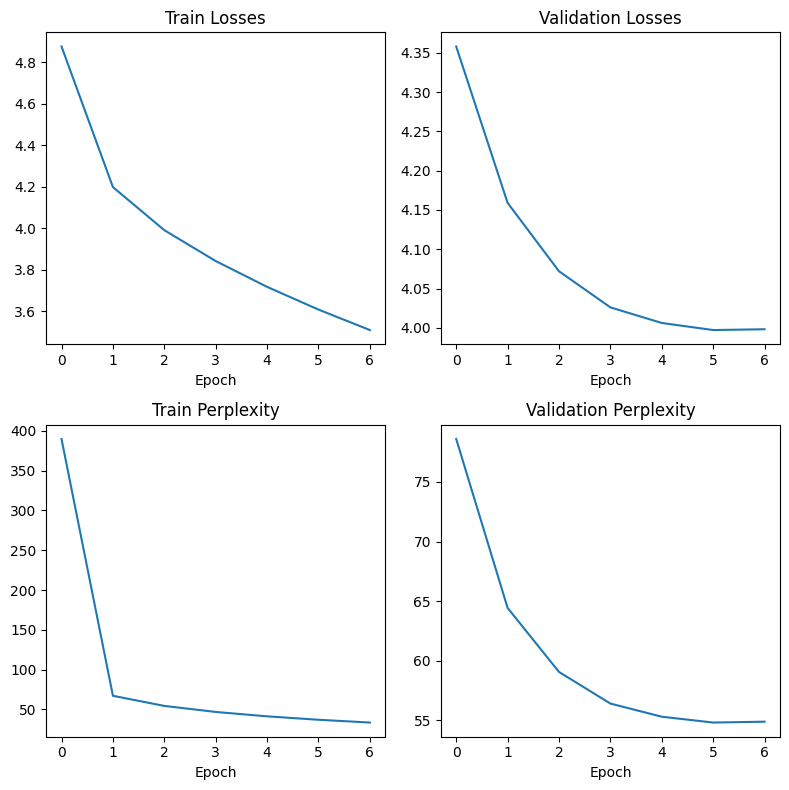

Perplexity on test:  54


In [ ]:
plot_all(losses_tr_exp_2, losses_val_exp_2, perplexities_tr_exp_2, perplexities_val_exp_2)
criterion = nn.CrossEntropyLoss(ignore_index=word2ind['<pad>'])
print('Perplexity on test: ', round(evaluate(model_2, criterion, test_dataloader)))

55. Wow. It's much better!

In [ ]:
(
generate_sequence(model_2, starting_seq='young d’artagnan arrived in paris with nothing but a sword and a dream to '),
generate_sequence(model_2, starting_seq='athos is a man who '),
generate_sequence(model_2, starting_seq='aramis believed that '),
generate_sequence(model_2, starting_seq='milady de winter, with a faint smile on her lips and a dagger in her sleeve, was ready to '),
generate_sequence(model_2, starting_seq='monte cristo knew that ')
)

('<bos> young d ’ artagnan arrived in paris with nothing but a sword and a dream to her . <eos>',
 "<bos> athos is a man who has been stolen from the <unk> of the king . '' <eos>",
 '<bos> aramis believed that he was not mistaken , but he was not mistaken . <eos>',
 '<bos> milady de winter , with a faint smile on her lips and a dagger in her sleeve , was ready to be able to see her . <eos>',
 '<bos> monte cristo knew that he was not mistaken , but he was not mistaken . <eos>')

In [ ]:
(
generate_sequence(model_2, starting_seq='is d’artagnan going to challenge him to a duel, or '),
generate_sequence(model_2, starting_seq='was athos ever able to forget milady, or '),
generate_sequence(model_2, starting_seq='does the count of monte cristo truly believe in justice, or '),
generate_sequence(model_2, starting_seq='who poisoned the wine at the cardinal’s banquet, and '),
generate_sequence(model_2, starting_seq='should edmond dantès reveal his true identity now, or ')
)

('<bos> is d ’ artagnan going to challenge him to a duel , or i ? <eos>',
 '<bos> was athos ever able to forget milady , or rather the king , who had not seen him . <eos>',
 "<bos> does the count of monte cristo truly believe in justice , or rather i am going to do so ? '' <eos>",
 '<bos> who poisoned the wine at the cardinal ’ s banquet , and the <unk> of the <unk> of the king of navarre was not a man to have been able to have been able to resign him . <eos>',
 '<bos> should edmond <unk> reveal his true identity now , or rather the <unk> to the king . <eos>')

In [ ]:
wrapper = ModelWrapper(model_2)

joblib_path = '/content/model_2_wrapper.joblib'
joblib.dump(wrapper, joblib_path)

files.download(joblib_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Further experiments will be continued by my colleague Yulia.**